# 01 — Data Understanding

Validate the ULB / Worldline transaction dataset, quantify the class imbalance, inspect data quality, and identify the modelling consequences before training any classifier.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_dataset

FIGURES = ROOT / 'outputs' / 'figures'
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)

In [2]:
transactions = load_dataset(ROOT / 'data' / 'creditcard.csv')
class_counts = transactions['Class'].value_counts().sort_index()
fraud_rate = transactions['Class'].mean()

summary = {
    'rows': int(len(transactions)),
    'features': int(transactions.shape[1] - 1),
    'legitimate_transactions': int(class_counts.get(0, 0)),
    'fraudulent_transactions': int(class_counts.get(1, 0)),
    'fraud_rate': float(fraud_rate),
    'missing_values': int(transactions.isna().sum().sum()),
    'duplicate_rows': int(transactions.duplicated().sum()),
}

summary

{'rows': 284807,
 'features': 30,
 'legitimate_transactions': 284315,
 'fraudulent_transactions': 492,
 'fraud_rate': 0.001727485630620034,
 'missing_values': 0,
 'duplicate_rows': 1081}

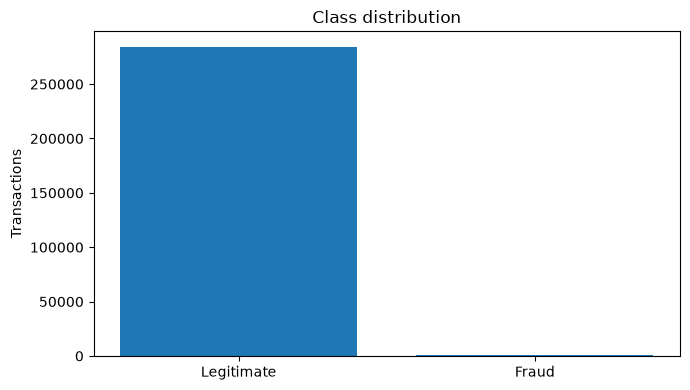

In [3]:
figure, axis = plt.subplots(figsize=(7, 4))
axis.bar(['Legitimate', 'Fraud'], [summary['legitimate_transactions'], summary['fraudulent_transactions']])
axis.set_title('Class distribution')
axis.set_ylabel('Transactions')
figure.tight_layout()
figure.savefig(FIGURES / '01_class_distribution.png', dpi=180)
plt.show()

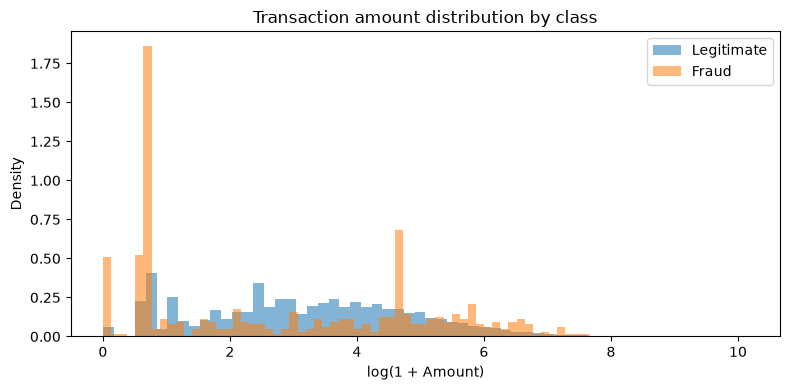

In [4]:
figure, axis = plt.subplots(figsize=(8, 4))
for label, name in [(0, 'Legitimate'), (1, 'Fraud')]:
    amounts = np.log1p(transactions.loc[transactions['Class'] == label, 'Amount'])
    axis.hist(amounts, bins=60, alpha=0.55, density=True, label=name)
axis.set_title('Transaction amount distribution by class')
axis.set_xlabel('log(1 + Amount)')
axis.set_ylabel('Density')
axis.legend()
figure.tight_layout()
figure.savefig(FIGURES / '02_amount_distribution.png', dpi=180)
plt.show()

In [5]:
with (METRICS / 'data_summary.json').open('w') as file:
    json.dump(summary, file, indent=2)

print(f"Fraud prevalence: {fraud_rate:.4%}")
print('Implication: accuracy is not a useful primary metric; PR-AUC and minority-class recall/precision are required.')

Fraud prevalence: 0.1727%
Implication: accuracy is not a useful primary metric; PR-AUC and minority-class recall/precision are required.


## Interpretation

The target is extremely imbalanced, so a classifier can achieve misleadingly high accuracy while failing to detect fraud. The benchmark therefore uses **PR-AUC as the primary model-selection metric**, with ROC-AUC, precision, recall and F1 as supporting measures. `V1`–`V28` remain anonymous PCA components and are not assigned invented business meanings.